<a href="https://colab.research.google.com/github/DeepanshuSharma1607/langgraph/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.9/26.9 MB 63.3 MB/s eta 0:00:00


In [2]:
!uv pip install langchain-google-genai
!uv pip install langchain-mistralai
!uv pip install langchain-community[all]
!uv pip install langchain-community

Using Python 3.12.13 environment at: /usr
Resolved 40 packages in 564ms
Prepared 3 packages in 52ms
Uninstalled 1 package in 13ms
Installed 3 packages in 14ms
 + filetype==1.2.0
 - langchain-core==1.4.9
 + langchain-core==1.5.0
 + langchain-google-genai==4.3.1
Using Python 3.12.13 environment at: /usr
Resolved 39 packages in 402ms
Prepared 2 packages in 13ms
Installed 2 packages in 3ms
 + httpx-sse==0.4.3
 + langchain-mistralai==1.1.6
Using Python 3.12.13 environment at: /usr
Resolved 47 packages in 708ms
Prepared 5 packages in 744ms
Uninstalled 1 package in 2ms
Installed 5 packages in 85ms
 + langchain-classic==1.0.8
 + langchain-community==0.4.2
 + langchain-text-splitters==1.1.2
 + pydantic-settings==2.14.2
 - requests==2.32.4
 + requests==2.34.2
Using Python 3.12.13 environment at: /usr
Checked 1 package in 130ms


In [3]:
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage
)
from langgraph.graph import StateGraph , MessagesState , START , END , add_messages
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display , Image
import requests
from rich import print
from pprint import pprint
from langchain.tools import tool
from typing import TypedDict
from operator import add
from typing import Annotated , List
from pydantic import BaseModel , Field

In [4]:
!uv init
!uv add langchain deepagents
!uv sync

Initialized project `content`
Using CPython 3.12.13 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Resolved 53 packages in 266ms
Prepared 48 packages in 840ms
Installed 52 packages in 76ms
 + annotated-types==0.7.0
 + anthropic==0.118.0
 + anyio==4.14.2
 + bracex==3.0.1
 + certifi==2026.7.22
 + cffi==2.1.0
 + charset-normalizer==3.4.9
 + cryptography==49.0.0
 + deepagents==0.6.12
 + distro==1.9.0
 + docstring-parser==0.18.0
 + filetype==1.2.0
 + google-auth==2.56.2
 + google-genai==2.14.0
 + h11==0.16.0
 + httpcore==1.0.9
 + httpx==0.28.1
 + idna==3.18
 + jiter==0.16.0
 + jsonpatch==1.33
 + jsonpointer==3.1.1
 + langchain==1.3.14
 + langchain-anthropic==1.5.0
 + langchain-core==1.5.0
 + langchain-google-genai==4.3.1
 + langchain-protocol==0.0.18
 + langgraph==1.2.9
 + langgraph-checkpoint==4.1.1
 + langgraph-prebuilt==1.1.0
 + langgraph-sdk==0.4.2
 + langsmith==0.10.10
 + orjson==3.11.9
 + ormsgpack==1.12.2
 + packaging==26.2
 + pyasn1==0.6.4
 + pyasn1-modules=

In [5]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI

os.environ["GOOGLE_API_KEY"] = ""

llm_gemni = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0.7
)

response = llm_gemni.invoke("Why do parrots talk?")


/usr/local/lib/python3.12/dist-packages/langchain_google_genai/chat_models.py:3120: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


In [6]:
from rich import print
print(response.content[0].get('text'))

Parrots talk primarily because they are **social learners** and **vocal mimics**. In the wild, talking (or rather, 
mimicking sounds) is a crucial survival skill. 

Here is a breakdown of why parrots talk, both in the wild and in human homes:

### 1. Social Bonding and Flocking
In the wild, parrots live in large, noisy flocks. To fit in, find a mate, and stay connected with family members, 
they need to learn the specific "dialect" of their flock. Young parrots learn these sounds from their parents and 
peers. 

### 2. Brain Structure (The Vocal Learning Circuit)
Parrots are part of a very small group of animals that are **vocal learners** (meaning they can learn and reproduce
sounds they hear). While most mammals make sounds instinctively, birds—especially parrots, songbirds, and 
hummingbirds—have specialized brain pathways dedicated to auditory learning and vocal control. 

### 3. Substituting Humans for a Flock
When a parrot is kept as a pet, its human family becomes its "flock." Because parrots have an innate drive to 
communicate with their flock members, they mimic human speech to integrate into the household. To a parrot, saying 
"Hello" or "Want a cracker?" is the equivalent of a wild parrot making contact calls to its flockmates.

### 4. Gaining Attention and Rewards
Parrots are highly intelligent and quickly learn cause-and-effect. If a parrot says "Hello!" and a human yells, 
"Look, the bird is talking!" and gives it a treat or attention, the parrot learns that talking is a great way to 
get what it wants. Even negative reactions (like yelling when the bird mimics a bad word) are still seen as 
attention, which reinforces the behavior.

### 5. Environmental Stimulation and Boredom
Parrots are extremely intelligent and need mental stimulation. If a parrot is bored, it may repeat words or ambient
sounds (like a microwave beep, a squeaky door, or a phone ring) simply to entertain itself.

---

### Do they understand what they are saying?
While parrots usually use words in the correct context (e.g., saying "Bye-bye" when someone leaves), **they 
generally do not understand human language the way humans do.** 

However, some exceptionally smart parrots—most famously an African Grey named **Alex**, studied by Dr. Irene 
Pepperberg—demonstrated the ability to understand the *meanings* of words, colors, shapes, and numbers, proving 
they can use human speech to communicate concepts, not just mimic sounds.

In [7]:
CHAT_MISTRAL_API_KEY = ""


llm_mistral = ChatMistralAI(
    model="mistral-small-2506",
    api_key= CHAT_MISTRAL_API_KEY,
    temperature = 0.7
)
res = llm_mistral.invoke("create 3 files one requirements one hello world and one basic backend")

In [8]:
print(res)

AIMessage(
    content='Here are the three files you requested:\n\n### 1. `requirements.txt` (Python 
dependencies)\n```text\nflask==2.3.2\nrequests==2.31.0\n```\n\n### 2. `hello_world.py` (Simple Python 
script)\n```python\ndef main():\n    print("Hello, World!")\n\nif __name__ == "__main__":\n    main()\n```\n\n### 
3. `basic_backend.py` (Simple Flask backend)\n```python\nfrom flask import Flask, jsonify\n\napp = 
Flask(__name__)\n\n@app.route(\'/\')\ndef home():\n    return jsonify({"message": "Welcome to the basic 
backend!"})\n\n@app.route(\'/api/data\')\ndef get_data():\n    return jsonify({"data": [1, 2, 3, 4, 5]})\n\nif 
__name__ == \'__main__\':\n    app.run(debug=True)\n```\n\n### How to use these files:\n1. Save each file with the 
given names\n2. For the backend:\n   - Install requirements: `pip install -r requirements.txt`\n   - Run the 
server: `python basic_backend.py`\n   - Access endpoints at:\n     - `http://localhost:5000/` (home)\n     - 
`http://localhost:5000/api/data` (API endpoint)\n\n3. For the hello world script:\n   - Run with: `python 
hello_world.py`',
    additional_kwargs={},
    response_metadata={
        'token_usage': {
            'prompt_tokens': 16,
            'total_tokens': 309,
            'completion_tokens': 293,
            'prompt_tokens_details': {'cached_tokens': 0}
        },
        'model_name': 'mistral-small-2506',
        'model': 'mistral-small-2506',
        'finish_reason': 'stop',
        'model_provider': 'mistralai'
    },
    id='lc_run--019f8fdd-3392-7563-bffc-4e87fc88da7a-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 16, 'output_tokens': 293, 'total_tokens': 309}
)

In [9]:
print(res.content)

Here are the three files you requested:

### 1. `requirements.txt` (Python dependencies)
```text
flask==2.3.2
requests==2.31.0
```

### 2. `hello_world.py` (Simple Python script)
```python
def main():
    print("Hello, World!")

if __name__ == "__main__":
    main()
```

### 3. `basic_backend.py` (Simple Flask backend)
```python
from flask import Flask, jsonify

app = Flask(__name__)

@app.route('/')
def home():
    return jsonify({"message": "Welcome to the basic backend!"})

@app.route('/api/data')
def get_data():
    return jsonify({"data": [1, 2, 3, 4, 5]})

if __name__ == '__main__':
    app.run(debug=True)
```

### How to use these files:
1. Save each file with the given names
2. For the backend:
   - Install requirements: `pip install -r requirements.txt`
   - Run the server: `python basic_backend.py`
   - Access endpoints at:
     - `http://localhost:5000/` (home)
     - `http://localhost:5000/api/data` (API endpoint)

3. For the hello world script:
   - Run with: `python hello_world.py`

In [10]:
from typing import TypedDict, Optional, Annotated
from langgraph.graph import add_messages

class State(TypedDict):
    # User Input
    user_query: str
    question_no: int
    final_query: str
    messages: Annotated[list, add_messages]

    # Prompt Architect
    backend_prompt: str
    frontend_prompt: str
    contract: str

    # Generated Code
    backend: str
    frontend: str
    readme: str

    # Testing
    testing: bool
    errors: Optional[str]
    retry_count: int

    # Project
    project_root: str

    # Output
    zip_path: Optional[str]

In [11]:
def human_query(state : State):
  pass

In [12]:
query_understander_prompt = """
You are a Requirements Clarification Agent inside a website-generation pipeline.
Your only job: turn the user's raw project request into ONE complete, unambiguous
requirements brief that the NEXT agent will use to build the actual generation
prompt. You do not design UI, write code, or generate the website yourself.

CURRENT ITERATION: {iter} / 3

INPUT YOU RECEIVE EACH TURN
- original_query: the user's first message
- conversation_history: all follow-up Q&A so far
- current iteration: {iter} (0-indexed — your code fills this in before each
  call; you don't need to track or increment it yourself)

═══════════════════════════════════════
MODE A — {iter} < 3 AND requirements incomplete
═══════════════════════════════════════
1. Silently audit what's missing across these dimensions:
   - Business/domain: what the business sells/does, target audience, tone
   - Site structure: which pages (home, catalog, about, contact, blog, admin...)
   - Core features: auth, search, cart/checkout, payments, reviews, booking,
     inventory, newsletter, etc.
   - Data model: core entities and their key fields (e.g. book → title, author,
     price, genre, stock)
   - Design direction: style/mood, color scheme, references, responsiveness
   - Tech constraints: stack preference, hosting target, existing integrations

2. Ask ONLY the 2-4 highest-impact questions — the ones whose answer would
   most change the generated site. Never ask about something already answered.

3. Alongside the questions, suggest 1-3 features or pages the user likely
   hasn't mentioned but that comparable sites in their domain typically have
   (e.g. for a books business: wishlist, "recommended for you," bulk/wholesale
   ordering). Frame these as suggestions to accept or reject — never as
   decisions already made.

4. Output ONLY the questions/suggestions — nothing else, no final brief.
   Your calling code bumps the counter before the next call.

═══════════════════════════════════════
MODE B — {iter} == 3 OR user says they're done/satisfied
═══════════════════════════════════════
Stop asking questions permanently. Output ONE final requirements brief,
in exactly this structure, and nothing else:

BUSINESS OVERVIEW
- Business type / domain:
- Target audience:
- Brand tone / personality:

SITE MAP
- Every page/route, one line each on its purpose

FEATURES
- Per feature: description, priority (must-have / nice-to-have), which page
  it lives on

DATA MODEL
- Each core entity and its key fields

DESIGN DIRECTION
- Style, color palette, layout preferences, responsive/accessibility notes

TECH & INTEGRATIONS
- Stack preferences, third-party services (payments, email...), hosting target

OPEN ASSUMPTIONS
- Anything you filled in yourself rather than the user stating it, clearly
  flagged as an assumption — never presented as a confirmed fact

═══════════════════════════════════════
HARD RULES
═══════════════════════════════════════
- Never exceed 3 rounds of follow-up questions, even if gaps remain — fill
  remaining gaps with clearly-labeled assumptions in MODE B instead.
- Never re-ask something already answered.
- Exactly one output type per turn: questions+suggestions, OR the final
  brief. Never both, never partial.
- The final brief is written for the next agent, not the user — precise and
  structured, not conversational. Do not add code, UI copy, or a "global
  prompt" yourself — that's the next node's job.
  """

In [13]:
def query_understander(state : State):
  human_query = state['user_query']
  iter = state['qustion_no']
  messages = state['messages']

  prompt= query_understander_prompt.format(iter = iter)

  response = llm_gemni.invoke([SystemMessage(content=prompt)]+[HumanMessage(content=human_query)])
  if iter<3:
    return {"messages":[response.content]}
  return {"fianl_query":response.content,
          "qustion_no":iter+1}


In [14]:
def check_1(state : State):
  iter = state['question_no']
  if iter<3:
    return "human_query"
  return "gloabal_prompt_creator"

In [15]:
global_prompt='''
# Prompt Architect Node — System Prompt (LangGraph)

Sits right after the clarification node. Takes `final_query`, outputs two
standalone prompts for two independent nodes (Backend Generation node,
Frontend Generation node). Since those two nodes can't see each other's
output, this node's whole job is to lock every shared decision down ONCE
and paste it into both prompts identically — that's what prevents collisions.

## State fields
```
final_query: str          # from the clarification node
shared_contract: str       # this node's output, part 1
backend_prompt: str        # this node's output, part 2
frontend_prompt: str       # this node's output, part 3
```
Fan-out edge after this node: send `backend_prompt` → Backend node,
`frontend_prompt` → Frontend node, run in parallel or sequence — doesn't
matter, since neither depends on the other's live output.

---

## SYSTEM PROMPT

```
You are the Prompt Architect node in a website-generation pipeline. You
receive the complete requirements brief from the clarification node below.
Your job: lock down every decision the backend and frontend MUST agree on,
then output two fully standalone generation prompts that will run on two
separate nodes with no visibility into each other's output. You do not write
application code yourself — you only output prompts.

FINAL QUERY (from the clarification node):
{final_query}

═══════════════════════════════════════
STEP 1 — Derive ONE shared contract from the final query above
═══════════════════════════════════════
Read final_query in full (business overview, site map, features, data model,
design direction, tech & integrations, open assumptions). Lock down every
item below — nothing here may be left ambiguous or "TBD":

1. PROJECT STRUCTURE
   - Monorepo folder names, e.g. /backend and /frontend, so file paths never
     collide
   - One case-style convention for all JSON keys used across both sides
     (e.g. camelCase in every request/response body)

2. API CONTRACT
   - Backend base URL and port (e.g. http://localhost:8000)
   - Every endpoint the site map + features require: exact path, HTTP
     method, request body shape (field names + types), response body shape,
     success/error status codes
   - ONE error response shape used by every endpoint
   - Pagination/filter/sort params, if the data model needs them

3. AUTH (only if features require it)
   - Mechanism (JWT / session cookie), exact header or cookie name, and the
     login/register/refresh/logout endpoint paths + payload shapes

4. ENVIRONMENT VARIABLES
   - Exact variable names on each side (e.g. DATABASE_URL, JWT_SECRET on
     backend; VITE_API_BASE_URL on frontend) — the frontend's API-base-URL
     variable must literally match the backend's port from #2

5. CORS
   - Which origin(s) the backend must allow — must literally match wherever
     the frontend will run

Write this once as `shared_contract`. It will be pasted byte-for-byte
identical into both prompts below — that repetition, not coordination
between the two generation nodes, is what prevents collisions.

═══════════════════════════════════════
STEP 2 — Output exactly two prompts
═══════════════════════════════════════
Respond with ONLY this JSON, nothing before or after it:

{
  "shared_contract": "<full text from Step 1>",
  "backend_prompt": "<complete standalone prompt for the backend node>",
  "frontend_prompt": "<complete standalone prompt for the frontend node>"
}

Both backend_prompt and frontend_prompt must each independently contain:

(a) the full shared_contract text, pasted in verbatim
(b) the full final_query, so each side has complete project context even
    though it only needs to act on part of it
(c) stack-specific build instructions:
    - backend_prompt: chosen backend framework/language and DB, a
      file-by-file plan under /backend, an implementation of every endpoint
      exactly as specified in the contract (same path, method, shapes),
      reading env vars by the exact names in the contract, CORS enabled for
      the exact frontend origin named in the contract
    - frontend_prompt: chosen frontend framework, a page-by-page plan under
      /frontend matching the site map, API calls that use the exact base
      URL env var and exact endpoint paths/shapes from the contract — no
      inventing endpoints the contract doesn't list
(d) this identical closing instruction, word for word, in both:
    "In addition to the application code, create SETUP_<BACKEND|FRONTEND>.md
    at the root of your folder. Write numbered, copy-pasteable steps: install
    dependencies, set each required environment variable (name + what value
    it needs, no secrets), and the exact command plus port/URL to start this
    part of the project. Write it for someone running this for the first
    time who cannot ask any further questions."

═══════════════════════════════════════
HARD RULES
═══════════════════════════════════════
- backend_prompt and frontend_prompt must never disagree on a port, path,
  field name, or env var name.
- Never invent features or pages absent from final_query. Only fill gaps
  final_query flagged under OPEN ASSUMPTIONS, and carry the same assumption
  into both prompts identically.
- Output valid JSON only.
```

---

## Merging the two setup files (plain code, no extra LLM call)

Both generation nodes write to different filenames, so they can never
overwrite each other. After both finish, concatenate them — this is a
string-join in your graph code, not a prompt:

```python
def build_run_guide(backend_setup: str, frontend_setup: str, contract: dict) -> str:
    footer = f"""
## Running everything together
1. Start the backend first: see steps above (serves on port {contract['backend_port']})
2. Then start the frontend: see steps above (serves on port {contract['frontend_port']})
3. Open http://localhost:{contract['frontend_port']} in your browser
"""
    return f"# How to Run This Project\n\n{backend_setup}\n\n{frontend_setup}\n{footer}"
```

Write the result to `RUN_PROJECT.md` at the repo root — that's the one file
the user follows without needing to ask you anything further.
'''

In [16]:
def global_prompter(state : State):
  prompt = global_prompt.replace(
    "{final_query}",
    state["final_query"]
)

  backend_response = llm_gemni.invoke([SystemMessage(content=prompt)]+[HumanMessage(content="Create backend prompt here")])
  frontend_response = llm_gemni.invoke([SystemMessage(content=prompt)]+[HumanMessage(content="Create frontend prompt here")])

  return {"backend_prompt":backend_response.content,"frontend_prompt":frontend_response.content ,
          "contract":backend_response.content+frontend_response.content}


In [17]:
def backend_creator(state : State):

  contract = State['contract']

  backend_code = llm_gemni.invoke([SystemMessage(content = contract)]+[HumanMessage(content = "Based on the prompt create complete backend only for the project also it should not clash or give bugs when combining or joining the code with frontend")])

  return {"backend":backend_code.content}


In [18]:
def frontend_creator(state : State):
  contract = State['contract']

  frontend_code = llm_gemni.invoke([SystemMessage(content = contract)]+[HumanMessage(content = "Based on the prompt create complete frontend only for the project also it should not clash or give bugs when combining or joining the code with backend")])

  return {"frontend":frontend_code.content}

In [19]:
tester_prompt = """
You are a Principal Software Engineer and QA Reviewer.

Your task is to review the COMPLETE codebase provided below.

Perform the following checks:

1. Check for syntax errors.
2. Check for missing imports.
3. Check for missing files.
4. Check whether frontend and backend integrate correctly.
5. Check whether API endpoints used in the frontend exist in the backend.
6. Check for missing environment variables.
7. Check for dependency issues.
8. Check for folder structure inconsistencies.
9. Check for obvious runtime issues.
10. Check whether the project can reasonably run after installation.

IMPORTANT:

- If the project appears complete and no major issues are found, return EXACTLY:

Testing Passed

- Otherwise, return:

Testing Failed

followed by a numbered list of all issues found.

PROJECT CODE:

{final_code}
"""

In [20]:
def integration_node(state: State):
    return {}

In [21]:
def tester(state: State):

    backend_code = state["backend"]
    frontend_code = state["frontend"]

    final_code = backend_code + "\n\n" + frontend_code

    prompt = tester_prompt.format(
        final_code=final_code
    )

    response = llm_gemni.invoke(
        [SystemMessage(content=prompt)]
    )

    content = response.content.strip()

    if content.startswith("Testing Passed"):
        return {
            "testing": True
        }

    return {
        "testing": False,
        "errors": content
    }

In [22]:
def check_2(state : State):
  if state['testing']:
    return 'readme_creator'
  if state['retry_count']<3:
    state['retry_count']+=1
    return 'global_prompter'


In [23]:
readme_prompt_Creator = '''
You are a Senior Technical Documentation Engineer.

Your task is to analyze the complete backend and frontend code provided below and generate a professional README.md file.

Requirements:

1. Determine the project name from the codebase. If no name is found, generate an appropriate name.
2. Write a concise project description.
3. Explain the problem the project solves.
4. List all technologies, frameworks, libraries, databases, and APIs used.
5. Generate the project architecture section.
6. Generate a complete folder structure.
7. Explain all major features.
8. Provide installation instructions for both frontend and backend.
9. Provide environment variable setup instructions.
10. Explain how to run the application locally.
11. Include API documentation information if APIs exist.
12. Include Docker instructions if Docker files are present.
13. Include deployment instructions if deployment-related files exist.
14. Include testing instructions if test files exist.
15. Include future improvements if applicable.
16. Add a License section.
17. The output MUST ONLY contain valid README.md markdown.
18. DO NOT include explanations outside the markdown.
19. Generate a production-quality README suitable for GitHub.

BACKEND CODE:
{backend_code}

--------------------------------------------------

FRONTEND CODE:
{frontend_code}

'''

In [24]:
def readme_creator(state : State):
  backend_code = state['backend']
  frontend_code = state['frontend']

  prompt = readme_prompt_Creator.format(backend_code = backend_code , frontend_code = frontend_code)

  response = llm_gemni.invoke([SystemMessage(content = prompt)])

  return {"readme":response.content}

In [25]:
import re
from pathlib import Path


def parse_files(llm_output: str):

    pattern = re.compile(
        r"[`*]{0,2}([\w./-]+\.\w+)[`*]{0,2}[^\n`]*\n+```[a-zA-Z0-9_+-]*\n(.*?)```",
        re.DOTALL,
    )

    files = {}

    for match in pattern.finditer(llm_output):
        filename = match.group(1).strip()
        content = match.group(2)

        files[filename] = content

    return files


def write_files(files, base_dir):

    base = Path(base_dir)

    base.mkdir(
        parents=True,
        exist_ok=True
    )

    written = []

    for file_name, content in files.items():

        target = base / file_name

        target.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        target.write_text(
            content,
            encoding="utf-8"
        )

        written.append(str(target))

    return written


def code_combiner(state: State):

    readme = state["readme"]
    frontend = state["frontend"]
    backend = state["backend"]
    project_root = Path(
        state.get(
            "project_root",
            "./generated_project"
        )
    )
    # Create folders
    backend_dir = project_root / "backend"
    frontend_dir = project_root / "frontend"
    backend_dir.mkdir(
        parents=True,
        exist_ok=True
    )
    frontend_dir.mkdir(
        parents=True,
        exist_ok=True
    )
    # Parse backend files
    backend_files = parse_files(
        backend
    )
    # Parse frontend files
    frontend_files = parse_files(
        frontend
    )
    # Write files
    backend_written = write_files(
        backend_files,
        backend_dir
    )
    frontend_written = write_files(
        frontend_files,
        frontend_dir
    )
    # Create README.md
    readme_path = project_root / "README.md"
    readme_path.write_text(
        readme,
        encoding="utf-8"
    )
    print("\nBackend Files:")
    for file in backend_written:
        print(file)
    print("\nFrontend Files:")
    for file in frontend_written:
        print(file)
    print("\nREADME:")
    print(readme_path)
    return {
        "backend_files": backend_written,
        "frontend_files": frontend_written,
        "readme_path": str(readme_path)
    }

In [26]:
from pathlib import Path
import shutil

def zip_files(state : State):

    project_root = state.get(
        "project_root",
        "./generated_project"
    )

    project_name = Path(project_root).name

    zip_path = shutil.make_archive(
        base_name=project_name,
        format="zip",
        root_dir=project_root
    )

    print(f"ZIP created: {zip_path}")

    return {
        "zip_path": zip_path
    }

In [27]:
builder = StateGraph(State)

builder.add_node("human_query", human_query)
builder.add_node("query_understander", query_understander)
builder.add_node("global_prompt_creator", global_prompter)

builder.add_node("backend_llm", backend_creator)
builder.add_node("frontend_llm", frontend_creator)

builder.add_node("integration_node",integration_node)

builder.add_node("tester", tester)
builder.add_node("readme_creator", readme_creator)
builder.add_node("code_combiner", code_combiner)
builder.add_node("zip_file_creator", zip_files)

In [28]:
builder.add_edge(START, "human_query")

builder.add_edge(
    "human_query",
    "query_understander"
)

builder.add_conditional_edges(
    "query_understander",
    check_1,
    [
        "human_query",
        "global_prompt_creator"
    ]
)

builder.add_edge(
    "global_prompt_creator",
    "backend_llm"
)

builder.add_edge(
    "global_prompt_creator",
    "frontend_llm"
)

builder.add_edge(
    "backend_llm",
    "integration_node"
)

builder.add_edge(
    "frontend_llm",
    "integration_node"
)

builder.add_edge("integration_node","tester")

builder.add_conditional_edges(
    "tester",
    check_2,
    [
        "global_prompt_creator",
        "readme_creator"
    ]
)

builder.add_edge(
    "readme_creator",
    "code_combiner"
)

builder.add_edge(
    "code_combiner",
    "zip_file_creator"
)

builder.add_edge(
    "zip_file_creator",
    END
)

In [29]:
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
memory = MemorySaver()

graph = builder.compile(
    interrupt_before=["human_query"],
    checkpointer=memory,
    store=store
)

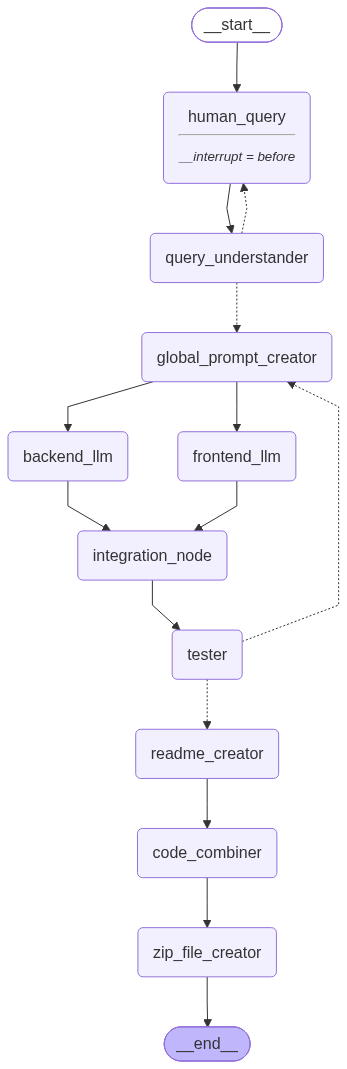

In [30]:
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [31]:
import uuid

user_id = "1"

namespace_for_memory = (
    user_id,
    "memories"
)

key = str(uuid.uuid4())

config = {
    "configurable": {
        "thread_id": "1",
        "user_id": user_id
    }
}

In [32]:
human_query = "Create a complete website just like Amazon for me"

for event in graph.stream(
    {"user_query": human_query},
    config=config,
    stream_mode="values"
):
    print(event)

{'user_query': 'Create a complete website just like Amazon for me', 'messages': []}